In [14]:
%%file requirements_emb.txt
transformers
datasets
matplotlib
pydub
torchcodec
torch

Overwriting requirements_emb.txt


In [2]:
import matplotlib.pyplot as pplot

from datasets import load_dataset
from transformers import ClapModel, ClapProcessor
from utils import _process_mp3, _get_chunks

model = ClapModel.from_pretrained("laion/clap-htsat-unfused")
model = model.to('cuda')
processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")

MAX_CHUNKS = 10
MAX_TRACKS = 3
def _get_emb(audios, sampling_rate = 48000):
    inputs = processor(audios=audios,sampling_rate = sampling_rate, return_tensors="pt").to('cuda')
    audio_embed = model.get_audio_features(**inputs)
    return audio_embed.mean(0)

def _preproc_track(track_path, max_chunks = MAX_CHUNKS):
    res = _process_mp3(track_path)
    res = _get_chunks(res)
    res = [r/32768.0 for r in res][:max_chunks]    
    return res 

def _get_emb_track_path(track_path, max_chunks = MAX_CHUNKS):
    res = _process_mp3(track_path)
    res = _get_chunks(res)
    res = [r/32768.0 for r in res][:max_chunks]
    return _get_emb(res)

/home/charilaos/Workspace/streetparade25_embedings/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sclib not installed


In [3]:
## Code to compute embeddings for the downloaded data
import os
import json

fpath_links = '/home/charilaos/Datasets/streetparade_25'
links_json_file = os.path.join(fpath_links, 'artist_links.json')
with open(links_json_file, 'r') as f:
    json_links = json.loads(f.read())

root_mp3 = os.path.join(fpath_links, '.songs_cache')

In [4]:
all_artists = [k for k in json_links.keys()]

In [ ]:
from utils import ArtistData
a = all_artists[0]
ad = ArtistData(a, json_links[a], cache_folder=root_mp3)

# Per-artist create a summary chunk file:
for a in ad:
    preproc_res = _preproc_track(a[1])
    break

In [ ]:
import numpy as np
np.hstack(preproc_res)
from pydub import AudioSegment
import hashlib

def _make_ogg_from_segments(segments, output_file = 'output_sound.mp3'):
# --- Use the same audio parameters and data from the previous example ---
    sample_rate = 48000
    audio_data_float = np.hstack(preproc_res)
    audio_data_int16 = np.int16(audio_data_float * 32767)


    # --- 1. Create a pydub AudioSegment from the NumPy array ---
    # We need to provide the raw data, sample width, frame rate, and channels.
    # sample_width=2 corresponds to 16-bit audio (2 bytes per sample).
    # channels=1 is for mono audio.
    sound = AudioSegment(
        data=audio_data_int16.tobytes(),
        sample_width=2,  # 2 bytes = 16 bits
        frame_rate=sample_rate,
        channels=1  # Mono
    )

    # --- 2. Export to a web-friendly format ---
    # Export as MP3
    sound.export(output_file, format="mp3", bitrate="192k")

def _make_example_from_track(artist, artist_sample_folder = 'artist_samples'):
    ad = ArtistData(a, json_links[a], cache_folder=root_mp3)
    
    fname = 'artist_' + hashlib.md5(ad.artist.encode('utf-8')).hexdigest() + '.mp3'    
    
    for a in ad:
        preproc_res = _preproc_track(a[1])
        break
    _make_ogg_from_segments(preproc_res, os.path.join(artist_sample_folder, fname))
    print("ok - written " , fname)

'artist_b5892c035b3e5673216b1e8ad9f5f4f9.mp3'

'7ubo'

In [18]:
!scp /tmp/output.mp3 ideapad:/tmp/output.mp3

output.mp3                                    100% 2111KB   3.9MB/s   00:00    


('https://soundcloud.com/7ubo/djkhaledgreece',
 '/home/charilaos/Datasets/streetparade_25/.songs_cache/b5892c035b3e5673216b1e8ad9f5f4f9/b8462e2867e890e1dc90ca4b6203982e.mp3')

In [ ]:

from utils import ArtistData
a = all_artists[0]
ad = ArtistData(a, json_links[a], cache_folder=root_mp3)

In [ ]:

# _tracks = []
# a = all_artists[0]
# ad = ArtistData(a, json_links[a], cache_folder=root_mp3)
# for track_link, local_path in tqdm(ad):
#     if os.path.exists(local_path):
#         _tracks.append(_get_emb_track_path(local_path).cpu().detach().numpy())
#         break
# return np.mean(_tracks, 0)

# _get_emb_track_path()

In [ ]:
# chunks = _get_chunks(_process_mp3(local_path))
# inputs = processor(audios=chunks,sampling_rate = 48000, return_tensors="pt",device = 'cuda').to('cuda')

In [ ]:
from tqdm import tqdm
import numpy as np
def get_artist_embedding(ad, max_tracks = MAX_TRACKS):
    _tracks = []
    for track_link, local_path in tqdm(ad):
        if os.path.exists(local_path):
            try:
                _tracks.append(_get_emb_track_path(local_path).cpu().detach().numpy())
                if len(_tracks) >= max_tracks:
                    break
            except:
                print("error proc ", local_path)
    if len(_tracks) > 1 :
        return np.mean(_tracks, 0) 
    else:
        return _tracks

artist_embeddings = []
artists_avail = []
for a in tqdm(all_artists):
    ad = ArtistData(a, json_links[a], cache_folder=root_mp3)
    artist_embeddings.append(get_artist_embedding(ad))
    artists_avail.append(a)
        


 40%|████      | 2/5 [00:02<00:03,  1.07s/it]
0it [00:00, ?it/s]1/155 [03:06<20:43,  8.63s/it]
 40%|████      | 2/5 [00:00<00:01,  2.37it/s]it]
0it [00:00, ?it/s]5/155 [03:40<18:17,  7.84s/it]
0it [00:00, ?it/s]


An error occurred: Decoding failed. ffmpeg returned error code: 234

Output from ffmpeg/avlib:

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-l

 10%|█         | 2/20 [00:20<03:00, 10.04s/it]t]
0it [00:00, ?it/s]0/155 [04:03<16:01,  7.13s/it]
 67%|██████▋   | 2/3 [00:01<00:00,  1.57it/s]it]
0it [00:00, ?it/s]4/155 [04:26<12:07,  5.55s/it]
 20%|██        | 2/10 [00:17<01:10,  8.87s/it]
0it [00:00, ?it/s]6/155 [04:44<14:48,  6.89s/it]
 40%|████      | 2/5 [00:07<00:10,  3.59s/it]it]
0it [00:00, ?it/s]4/155 [09:34<24:35, 13.29s/it]
0it [00:00, ?it/s]
 33%|███▎      | 51/155 [10:55<19:52, 11.47s/it]

error proc  /home/charilaos/Datasets/streetparade_25/.songs_cache/2a2542f9e61a9a1d3b83ae31889ac954/1aa47cddf9dd17061f1c3877172cb011.mp3


 35%|███▍      | 54/155 [11:33<19:38, 11.67s/it]

...

 58%|█████▊    | 90/155 [12:05<00:31,  2.08it/s]

error proc  /home/charilaos/Datasets/streetparade_25/.songs_cache/8f0b0d4662811f7e23d5995943c14cb5/986b932be2a86be6ea954e975403d6ee.mp3


 58%|█████▊    | 90/155 [12:11<08:47,  8.12s/it]


KeyboardInterrupt: 

KeyboardInterrupt: 

In [4]:
# len(artist_embeddings), len(artists_avail)
_dat = [(n, a) for n , a in zip(artists_avail, artist_embeddings) if not isinstance(a, list)]
_final_avail_art = [d[0] for d in _dat]
_final_emb_dat = [d[1] for d in _dat]

NameError: name 'artists_avail' is not defined

In [ ]:
import pickle as pcl
with open("available_art.pcl",'wb') as f:
    pcl.dump(_final_avail_art, f)
with open("available_emb.pcl",'wb') as f:
    pcl.dump(_final_emb_dat,f)

In [30]:
from sklearn.manifold import TSNE
c = TSNE().fit_transform(np.stack(_final_emb_dat))

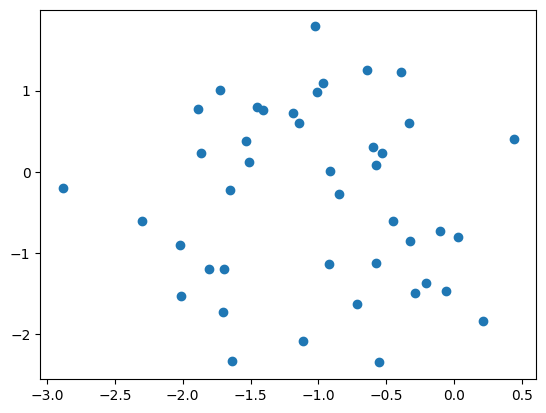

In [34]:
import matplotlib.pyplot as pplot
pplot.plot(c[:,0], c[:,1],'o')

In [28]:
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 37.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.7/307.7 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 41.8 MB/s eta 0:00:0000:0100:01


In [ ]:
[a.shape for a in artist_embeddings]

[(512,),
 (512,),
 (512,),
 (512,),
 (512,),
 (512,),
 (512,),
 (512,),
 (512,),
 (),
 (512,),
 (),
 (512,),
 (512,),
 (512,),
 (),
 ()]

[]

In [ ]:
import torch

# 1. Check if a CUDA-enabled GPU is available
is_gpu_available = torch.cuda.is_available()
is_gpu_available

True

In [ ]:
import numpy as np
import matplotlib.pyplot as pplot
from IPython.display import Audio
Audio(audio_sample["audio"]["array"], rate = 8000)

In [ ]:
pplot.plot(audio_sample["audio"]["array"])

In [ ]:
!pip install ffmpeg